### IN TERMINAL, open a terminal in /Molecular Docking (Copy and Paste and Run for each step)

First, we will use PDBFixer to clean the structure and add missing hydrogens at a physiological pH (7.4): 

His sites 218, 222, 228 

center at ZN1(301) site chain A 33.139  41.189  -4.257

### IN NOTEBOOK (Run all the cells)

In [2]:
import csv
import pandas as pd
import matplotlib.pyplot as plt

# Extract only the table into a CSV file
def extract_result(input_file, csv_file): 
    with open(input_file, 'r') as f:
        lines = f.readlines()

    data_rows = []
    start_collecting = False
    
    for line in lines:
        if '-----+' in line:
            start_collecting = True
            continue
        
        if start_collecting and line.strip():
            parts = line.split()
            if parts and parts[0].isdigit():
                data_rows.append(parts[1:])

    with open(csv_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['affinity', 'rmsd_lb', 'rmsd_ub'])
        writer.writerows(data_rows)

In [3]:
n=20 #number of ligands

In [4]:
for i in range(0, n+1):
    extract_result(f'./results/log_ligand_{i}.txt', f'./table_results/table_ligand_{i}.csv')
    #table_list.append(f'table_ligand_{i}.csv')

In [5]:
#Extract the affinity of mode 1 into a dictionary
best_affinity = {}

for i in range(0, n+1):
    df = pd.read_csv(f'./table_results/table_ligand_{i}.csv')
    best_affinity.update({f'ligand_{i}' : df['affinity'].iloc[1]})
    
print(best_affinity)

#Sort 20 ligands from lowest to highest affinity
sort_affinity = dict(sorted(best_affinity.items(), key=lambda item: item[1]))

print(sort_affinity)

{'ligand_0': np.float64(-9.351), 'ligand_1': np.float64(-8.964), 'ligand_2': np.float64(-9.646), 'ligand_3': np.float64(-7.63), 'ligand_4': np.float64(-9.086), 'ligand_5': np.float64(-8.023), 'ligand_6': np.float64(-8.976), 'ligand_7': np.float64(-7.953), 'ligand_8': np.float64(-9.641), 'ligand_9': np.float64(-9.691), 'ligand_10': np.float64(-9.015), 'ligand_11': np.float64(-8.846), 'ligand_12': np.float64(-7.467), 'ligand_13': np.float64(-7.784), 'ligand_14': np.float64(-8.87), 'ligand_15': np.float64(-7.191), 'ligand_16': np.float64(-7.581), 'ligand_17': np.float64(-8.502), 'ligand_18': np.float64(-8.846), 'ligand_19': np.float64(-7.784), 'ligand_20': np.float64(-8.87)}
{'ligand_9': np.float64(-9.691), 'ligand_2': np.float64(-9.646), 'ligand_8': np.float64(-9.641), 'ligand_0': np.float64(-9.351), 'ligand_4': np.float64(-9.086), 'ligand_10': np.float64(-9.015), 'ligand_6': np.float64(-8.976), 'ligand_1': np.float64(-8.964), 'ligand_14': np.float64(-8.87), 'ligand_20': np.float64(-8.87

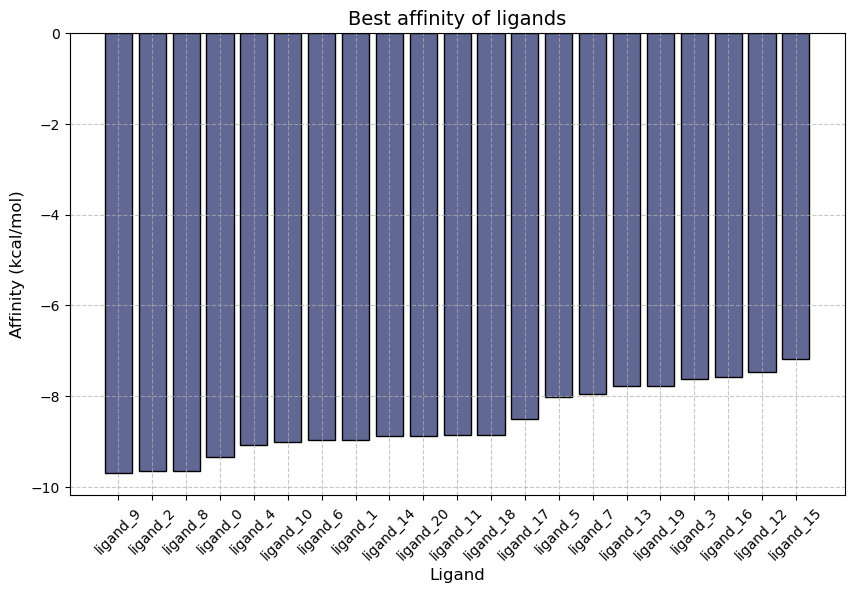

In [6]:
#Show the affinity of all 20 ligands
plt.figure(figsize=(10, 6))

plt.bar(sort_affinity.keys(), sort_affinity.values(), color='#626894', edgecolor='black')

plt.title('Best affinity of ligands', fontsize=14)
plt.xlabel('Ligand', fontsize=12)
plt.ylabel('Affinity (kcal/mol)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

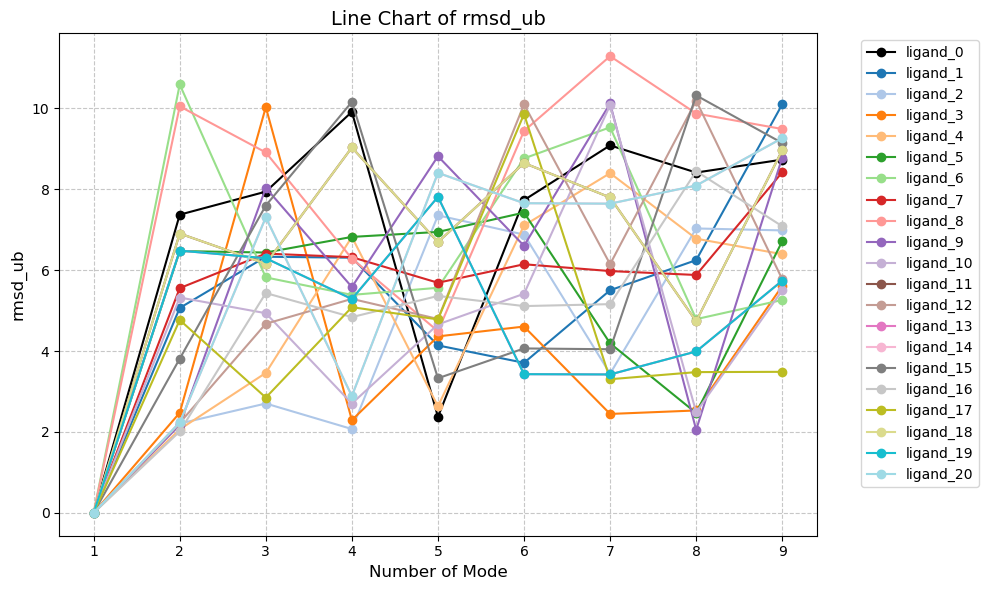

In [7]:
#Plot rmsd_ub of all 20 ligands
plt.figure(figsize=(10, 6))

df = pd.read_csv(f'./table_results/table_ligand_0.csv')
plt.plot(df['rmsd_ub'] , marker='o', linestyle='-', color='k', label=f'ligand_0')

cmap = plt.cm.tab20

for i in range(1, 21):
    df = pd.read_csv(f'./table_results/table_ligand_{i}.csv')
    plt.plot(df['rmsd_ub'] , marker='o', linestyle='-', color=cmap(i-1), label=f'ligand_{i}')

plt.title(f'Line Chart of rmsd_ub', fontsize=14)
plt.xlabel('Number of Mode', fontsize=12)
plt.ylabel('rmsd_ub', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.xticks(range(9), range(1, 10))
plt.show()

LIGAND 9 Rebimastat
LIGAND 2 Marimastat
LIGAND 8 TAPI-1

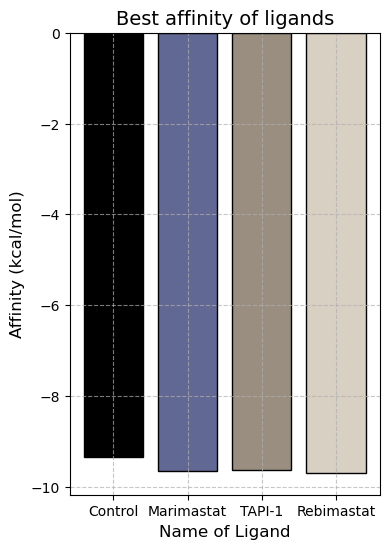

In [8]:
#Show the affinity of control and 3 ligands
plt.figure(figsize=(4, 6))

plt.bar('Control', sort_affinity['ligand_0'], color='black', edgecolor='black')
plt.bar('Marimastat', sort_affinity['ligand_2'], color='#626894', edgecolor='black')
plt.bar('TAPI-1', sort_affinity['ligand_8'], color='#9A8E80', edgecolor='black')
plt.bar('Rebimastat', sort_affinity['ligand_9'], color='#D8D0C2', edgecolor='black')

plt.title('Best affinity of ligands', fontsize=14)
plt.xlabel('Name of Ligand', fontsize=12)
plt.ylabel('Affinity (kcal/mol)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

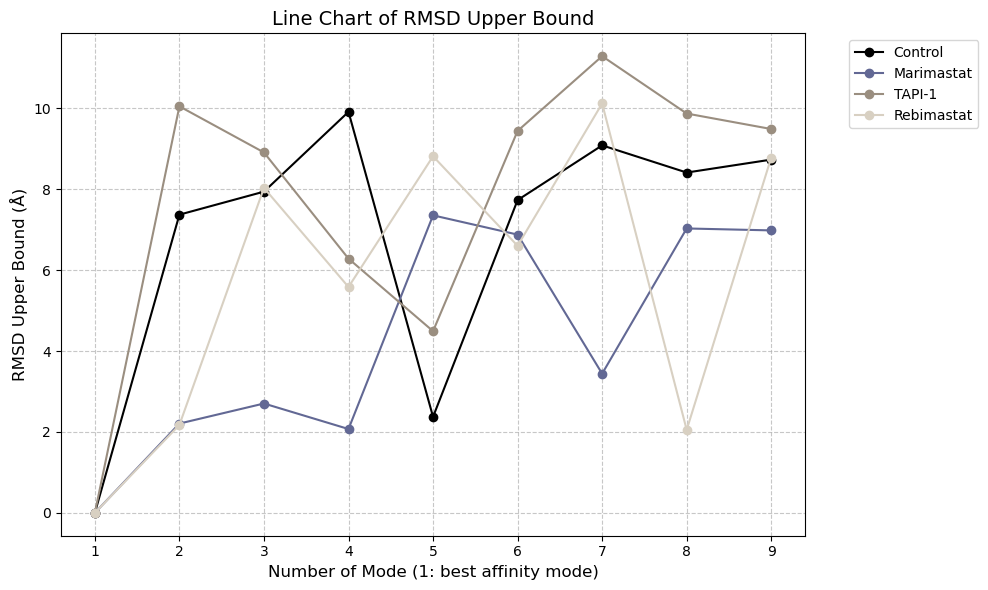

In [9]:
#Plot rmsd_ub of control and 3 ligands
plt.figure(figsize=(10, 6))

df = pd.read_csv(f'./table_results/table_ligand_0.csv')
plt.plot(df['rmsd_ub'] , marker='o', linestyle='-', color='k', label=f'Control')

cmap = plt.cm.tab20

df = pd.read_csv(f'./table_results/table_ligand_2.csv')
plt.plot(df['rmsd_ub'] , marker='o', linestyle='-', color='#626894', label=f'Marimastat')

df = pd.read_csv(f'./table_results/table_ligand_8.csv')
plt.plot(df['rmsd_ub'] , marker='o', linestyle='-', color='#9A8E80', label=f'TAPI-1')

df = pd.read_csv(f'./table_results/table_ligand_9.csv')
plt.plot(df['rmsd_ub'] , marker='o', linestyle='-', color='#D8D0C2', label=f'Rebimastat')

plt.title(f'Line Chart of RMSD Upper Bound', fontsize=14)
plt.xlabel('Number of Mode (1: best affinity mode)', fontsize=12)
plt.ylabel('RMSD Upper Bound (Å)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.xticks(range(9), range(1, 10))
plt.show()